# Cadena de Racha de Éxitos

**Modelo de Luis Rincón (2012), §3.2, pp. 33–34**

Sea $\{\xi_1, \xi_2, \ldots\}$ una sucesión de ensayos de Bernoulli independientes con probabilidad de éxito $p$ y de fracaso $q = 1-p$. Se define $X_n$ como el número de éxitos consecutivos previos al tiempo $n$, incluyendo el tiempo $n$.

El espacio de estados es $S = \{0, 1, 2, \ldots\}$ y las probabilidades de transición son:

$$p_{ij} = \begin{cases} p & \text{si } j = i+1 \\ q & \text{si } j = 0 \\ 0 & \text{otro caso} \end{cases}$$

In [1]:
import tkinter as tk
from tkinter import ttk
import random
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import numpy as np

#Parámetros iniciales para la simulación
p = 0.4    # Probabilidad de éxito 
q = 1 - p  # Probabilidad de fracaso 
N = 3     # Longitud de la racha a conseguir
racha_inicial = 0

### 1. Matrices de Transición

#### A) Matriz de Transición Original (Recurrente Continua)

$$P = \begin{pmatrix}
q & p & 0 & 0 & \cdots & 0 & 0 \\
q & 0 & p & 0 & \cdots & 0 & 0 \\
q & 0 & 0 & p & \cdots & 0 & 0 \\
\vdots & \vdots & \vdots & \vdots & \ddots & \vdots & \vdots \\
q & 0 & 0 & 0 & \cdots & 0 & p \\
q & p & 0 & 0 & \cdots & 0 & 0 
\end{pmatrix}$$

#### B) Matriz de Transición Modificada (Absorbente)

$$P = \begin{pmatrix}
q & p & 0 & 0 & \cdots & 0 & 0 \\
q & 0 & p & 0 & \cdots & 0 & 0 \\
q & 0 & 0 & p & \cdots & 0 & 0 \\
\vdots & \vdots & \vdots & \vdots & \ddots & \vdots & \vdots \\
q & 0 & 0 & 0 & \cdots & 0 & p \\
0 & 0 & 0 & 0 & \cdots & 0 & 1 
\end{pmatrix}$$

In [ ]:
def construir_matriz_transicion(p: float, N: int) -> np.ndarray:
    q = 1 - p
    P = np.zeros((N + 1, N + 1))

    for estado_actual in range(N):
        P[estado_actual, estado_actual + 1] = p
        P[estado_actual, 0] = q

    P[N, 1] = p
    P[N, 0] = q
    
    return P

matriz_P = construir_matriz_transicion(p, N)

matriz_P_absorbente = matriz_P.copy()
matriz_P_absorbente[N, :] = 0.0
matriz_P_absorbente[N, N] = 1.0

def imprimir_matriz(matriz):
    print(" " * 15, end="")
    for destino in range(matriz.shape[1]):
        print(f"   {destino:^5}   ", end="")
    print("\n" + "-" * (15 + 8 * matriz.shape[1]))

    for origen in range(matriz.shape[0]):
        print(f"      Estado {origen}     |", end="")
        for destino in range(matriz.shape[1]):
            valor = matriz[origen, destino]
            print(f"   {valor:5.2f}  ", end="")
        print()
    print("\n")

imprimir_matriz(matriz_P)
imprimir_matriz(matriz_P_absorbente)

                    0          1          2          3     
-----------------------------------------------
      Estado 0     |    0.60      0.40      0.00      0.00  
      Estado 1     |    0.60      0.00      0.40      0.00  
      Estado 2     |    0.60      0.00      0.00      0.40  
      Estado 3     |    0.60      0.40      0.00      0.00  


                    0          1          2          3     
-----------------------------------------------
      Estado 0     |    0.60      0.40      0.00      0.00  
      Estado 1     |    0.60      0.00      0.40      0.00  
      Estado 2     |    0.60      0.00      0.00      0.40  
      Estado 3     |    0.00      0.00      0.00      1.00  




### 2. Parámetros iniciales y simulación

Esta celda define la simulación y la interfaz gráfica.
En modo "Infinito" la cadena sigue después de alcanzar la racha N.
En modo "Absorbente" la simulación se detiene al llegar a N.

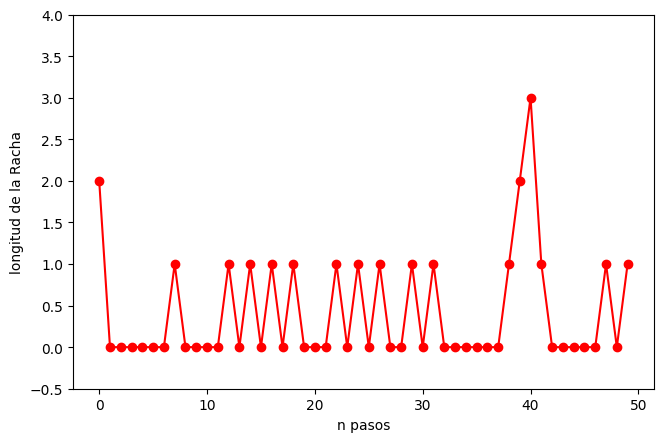

In [ ]:
racha_actual = racha_inicial
historial_rachas = [racha_inicial]
historial_letras = []
corriendo = False

def simular_paso():
    global racha_actual, corriendo

    if not corriendo:
        return

    modo_elegido = combo_modo.get()

    val = random.random()
    if val < p:
        historial_letras.append('p')
        if modo_elegido == "Infinito":
            if racha_actual == N:
                racha_actual = 1
            else:
                racha_actual += 1
        elif modo_elegido == "Absorbente":
            racha_actual += 1
    else:
        historial_letras.append('q')
        racha_actual = 0

    historial_rachas.append(racha_actual)
    if len(historial_rachas) > 50:
        historial_rachas.pop(0)

    ax.clear()
    ax.plot(historial_rachas, color="red", marker="o", linestyle="-")
    ax.set_ylabel("longitud de la Racha")
    ax.set_xlabel("n pasos")
    ax.set_ylim(-0.5, max(max(historial_rachas) + 1, N))
    canvas.draw()

    if modo_elegido == "Absorbente" and racha_actual == N:
        corriendo = False
        boton_iniciar.config(state="normal")
        boton_parar.config(state="disabled")
        combo_modo.config(state="readonly")
        print(historial_letras)
        return

    ventana.after(500, simular_paso)


def iniciar():
    global corriendo, racha_actual, historial_rachas, historial_letras
    if not corriendo:
        racha_actual = racha_inicial
        historial_rachas = [racha_inicial]
        historial_letras = []
        corriendo = True
        boton_iniciar.config(state="disabled")
        boton_parar.config(state="normal")
        combo_modo.config(state="disabled")
        simular_paso()


def parar():
    global corriendo
    corriendo = False
    boton_iniciar.config(state="normal")
    boton_parar.config(state="disabled")
    combo_modo.config(state="readonly")
    print(historial_letras)

ventana = tk.Tk()
ventana.title("Simulador de Rachas de Éxitos")
ventana.geometry("750x550")

frame_controles = ttk.Frame(ventana)
frame_controles.pack(pady=15)

combo_modo = ttk.Combobox(frame_controles, values=["Infinito", "Absorbente"], width=20)
combo_modo.current(0)
combo_modo.config(state="readonly")
combo_modo.pack(side="left", padx=10)

boton_iniciar = ttk.Button(frame_controles, text="Iniciar", command=iniciar)
boton_iniciar.pack(side="left", padx=5)

boton_parar = ttk.Button(frame_controles, text="Parar", command=parar, state="disabled")
boton_parar.pack(side="left", padx=5)

fig, ax = plt.subplots(figsize=(6, 3.5), dpi=100)
canvas = FigureCanvasTkAgg(fig, master=ventana)
canvas.get_tk_widget().pack(pady=5, fill="both", expand=True)

ax.plot(historial_rachas, color="red", marker="o", linestyle="-")
ax.set_ylabel("longitud de la Racha")
ax.set_xlabel("n pasos")
ax.set_ylim(-0.5, N)
canvas.draw()

ventana.mainloop()

In [4]:
# Simulación rápida para el caso absorbente
racha_actual = 0  
historial_rachas = [0]
historial_letras = []

while racha_actual < N:
    val = random.random()
    if val < p:
        historial_letras.append('p')
        racha_actual += 1
    else:
        historial_letras.append('q')
        racha_actual = 0
    historial_rachas.append(racha_actual)

print(historial_letras)

['q', 'q', 'p', 'p', 'q', 'p', 'q', 'q', 'p', 'q', 'q', 'q', 'p', 'p', 'p']


### 3. Clases de comunicación

Este bloque toma la secuencia simulada de éxitos y fracasos y busca
qué estados se conectan entre sí. Muestra si la cadena es absorbente
(estado N estable) o si todos los estados forman una sola clase.

In [ ]:
letras_simuladas = historial_letras
rachas_paso_a_paso = []
racha_actual = 0

es_absorbente = False
racha_prueba = 0
for letra in letras_simuladas:
    if letra == 'p':
        racha_prueba += 1
    else:
        racha_prueba = 0
if racha_prueba == N:
    es_absorbente = True

for letra in letras_simuladas:
    if letra == 'p':
        if not es_absorbente and racha_actual == N:
            racha_actual = 1
        else:
            racha_actual += 1
    else:
        racha_actual = 0
    rachas_paso_a_paso.append(racha_actual)

conexiones_encontradas = set()
for t in range(len(rachas_paso_a_paso) - 1):
    origen = rachas_paso_a_paso[t]
    destino = rachas_paso_a_paso[t+1]
    if origen != destino:
        conexiones_encontradas.add((origen, destino))

print("Estados accesibles:")
for origen, destino in sorted(conexiones_encontradas):
    print(f"  {origen} a {destino}")

estados_visitados = sorted(list(set(rachas_paso_a_paso)))

print("\nClases de comunicación:")
if es_absorbente:
    estados_transitorios = [e for e in estados_visitados if e < N]
    if estados_transitorios:
        cadena_transitorios = " = ".join(f"C({estado})" for estado in estados_transitorios)
        print(f"  Clase Transitoria: {cadena_transitorios}")
    if N in estados_visitados:
        print(f"  Clase Absorbente: C({N})")
else:
    cadena_igualdad = " = ".join(f"C({estado})" for estado in estados_visitados)
    print(f"  Clase Única (Irreducible): {cadena_igualdad}")

Estados accesibles:
  0 a 1
  1 a 0
  1 a 2
  2 a 0
  2 a 3

Clases de comunicación:
  Clase Transitoria: C(0) = C(1) = C(2)
  Clase Absorbente: C(3)


In [ ]:
# Clases de comunicación: accesibilidad y clasificación de estados

def calcular_accesibilidad(P):
    """Calcula qué estados son accesibles desde cada uno."""
    n = P.shape[0]
    acc = np.zeros((n, n), dtype=bool)
    for i in range(n):
        for j in range(n):
            if P[i, j] > 0:
                acc[i, j] = True
        acc[i, i] = True

    for k in range(n):
        for i in range(n):
            for j in range(n):
                if acc[i, k] and acc[k, j]:
                    acc[i, j] = True
    return acc


def calcular_clases_comunicacion(P):
    """Encuentra las clases de comunicación a partir de accesibilidad mutua."""
    n = P.shape[0]
    acc = calcular_accesibilidad(P)

    visitado = [False] * n
    clases = []

    for i in range(n):
        if visitado[i]:
            continue
        clase_i = []
        for j in range(n):
            if acc[i, j] and acc[j, i]:
                clase_i.append(j)
                visitado[j] = True
        clases.append(sorted(clase_i))

    return clases, acc


def es_clase_cerrada(clase, acc, n_estados):
    """Retorna True si no hay salida desde la clase hacia fuera."""
    clase_set = set(clase)
    for i in clase:
        for j in range(n_estados):
            if j not in clase_set and acc[i, j]:
                return False
    return True


def clasificar_estados(P, clases, acc, nombre=""):
    """Clasifica cada estado en transitorio o recurrente."""
    n = P.shape[0]
    clasificacion = {}

    clases_cerradas = []
    for clase in clases:
        if es_clase_cerrada(clase, acc, n):
            clases_cerradas.append(clase)

    for clase in clases:
        if not es_clase_cerrada(clase, acc, n):
            for estado in clase:
                clasificacion[estado] = "Transitorio"

    for clase in clases:
        for e in clase:
            clasificacion[e] = clasificacion.get(e, "")

    for clase in clases_cerradas:
        idx = np.array(clase)
        P_sub = P[np.ix_(idx, idx)]

        if len(clase) == 1:
            clasificacion[clase[0]] = "Recurrente Positivo (Absorbente)"
            continue

        A = (P_sub.T - np.eye(len(clase)))
        A[-1, :] = 1.0
        b = np.zeros(len(clase))
        b[-1] = 1.0

        try:
            pi_sub = np.linalg.solve(A, b)
            for k, estado in enumerate(clase):
                if pi_sub[k] > 1e-10:
                    mu_ii = 1.0 / pi_sub[k]
                    clasificacion[estado] = f"Recurrente Positivo (μ={mu_ii:.4f})"
                else:
                    clasificacion[estado] = "Recurrente Nulo"
        except np.linalg.LinAlgError:
            for estado in clase:
                clasificacion[estado] = "Recurrente (no determinado)"

    print(f"{'═'*55}")
    print(f"  Clasificación de estados — Cadena {nombre}")
    print(f"{'═'*55}")
    print(f"{'Estado':^10} | {'Clasificación'}")
    print("-" * 55)
    for estado in range(n):
        print(f"  {estado:^8} | {clasificacion.get(estado, 'No determinado')}")
    print()

    return clasificacion

clases_rec, acc_rec = calcular_clases_comunicacion(matriz_P)
clases_abs, acc_abs = calcular_clases_comunicacion(matriz_P_absorbente)

clf_rec = clasificar_estados(matriz_P, clases_rec, acc_rec, nombre="Recurrente")
clf_abs = clasificar_estados(matriz_P_absorbente, clases_abs, acc_abs, nombre="Absorbente")

═══════════════════════════════════════════════════════
  Cadena Recurrente
═══════════════════════════════════════════════════════

Accesibilidad directa (transiciones con prob > 0):
  Estado 0 → Estado 1  (prob = 0.40)
  Estado 1 → Estado 0  (prob = 0.60)
  Estado 1 → Estado 2  (prob = 0.40)
  Estado 2 → Estado 0  (prob = 0.60)
  Estado 2 → Estado 3  (prob = 0.40)
  Estado 3 → Estado 0  (prob = 0.60)
  Estado 3 → Estado 1  (prob = 0.40)

Clases de comunicación encontradas: 1
  Clase 1: estados {0, 1, 2, 3}  →  Recurrente cerrada

═══════════════════════════════════════════════════════
  Cadena Absorbente
═══════════════════════════════════════════════════════

Accesibilidad directa (transiciones con prob > 0):
  Estado 0 → Estado 1  (prob = 0.40)
  Estado 1 → Estado 0  (prob = 0.60)
  Estado 1 → Estado 2  (prob = 0.40)
  Estado 2 → Estado 0  (prob = 0.60)
  Estado 2 → Estado 3  (prob = 0.40)

Clases de comunicación encontradas: 2
  Clase 1: estados {0, 1, 2}  →  Transitoria (no cerra

### 4. Clasificación de los estados

En esta celda clasificamos los estados según su clase:
- clase cerrada → estados recurrentes
- clase abierta → estados transitorios

In [ ]:
print("═" * 60)
print("  A) VERSIÓN RECURRENTE")
print("═" * 60)

print("\n── 1. Distribución de X_n (partiendo del estado 0) ──")
print(f"{'n':>5} | " + " ".join(f"P(X_n={j})" for j in range(N + 1)))
print("-" * (7 + 12 * (N + 1)))

mu = np.zeros(N + 1)
mu[0] = 1.0

for n in range(N + 3):
    fila = f"{n:>5} | " + " ".join(f"  {mu[j]:.4f}  " for j in range(N + 1))
    print(fila)
    mu = mu @ matriz_P

print("\n  Interpretación: cada fila es P(X_n = j) para j = 0, 1, ..., N")

print("\n── 2. Distribución Estacionaria π ──")
n_estados = N + 1
A = (matriz_P.T - np.eye(n_estados))
A[-1, :] = 1.0
b = np.zeros(n_estados)
b[-1] = 1.0
pi = np.linalg.solve(A, b)

print("\n  Estado i  |  π_i (prob. estacionaria)  |  μ_ii = 1/π_i (tiempo medio retorno)")
print("  " + "-" * 65)
for i in range(n_estados):
    mu_ii = 1.0 / pi[i] if pi[i] > 1e-12 else float('inf')
    print(f"     {i:^5}  |         {pi[i]:.6f}           |       {mu_ii:.4f} pasos")

print(f"\n  Verificación: Σπ_i = {np.sum(pi):.6f}  (debe ser 1.0)")
print(f"  Verificación: π·P  ≈ π  →  max|π·P - π| = {np.max(np.abs(pi @ matriz_P - pi)):.2e}")

print("\n── 3. Probabilidades de transición P^n[i,j] ──")
for n_pasos in [1, 2, N, 2*N]:
    Pn_actual = np.linalg.matrix_power(matriz_P, n_pasos)
    print(f"\n  P^{n_pasos} (después de {n_pasos} pasos):")
    encabezado = "         " + "".join(f"   j={j}  " for j in range(n_estados))
    print(encabezado)
    for i in range(n_estados):
        fila = f"  i={i}  |" + "".join(f"  {Pn_actual[i,j]:.4f}" for j in range(n_estados))
        print(fila)

print(f"\n  Nota: cuando n → ∞, cada fila de P^n converge a π = {np.round(pi, 4)}")

print("\n── 4. Tiempos medios de recurrencia μ_ii ──")
print("  (Tiempo esperado para volver al estado i, partiendo de i)")
print()
for i in range(n_estados):
    mu_ii = 1.0 / pi[i]
    if i == 0:
        desc = "  ← tiempo medio entre dos rachas (fracasos)"
    elif i == N:
        desc = "  ← tiempo medio entre dos rachas completas de longitud N"
    else:
        desc = f"  ← tiempo medio entre dos visitas al nivel {i} de racha"
    print(f"  μ_{i}{i} = 1/π_{i} = {mu_ii:.4f} pasos{desc}")

print("\n\n" + "═" * 60)
print("  B) VERSIÓN ABSORBENTE")
print("═" * 60)

estados_transitorios_abs = list(range(N))
Q = matriz_P_absorbente[np.ix_(estados_transitorios_abs, estados_transitorios_abs)]
I_Q = np.eye(len(estados_transitorios_abs)) - Q
N_fund = np.linalg.inv(I_Q)
tiempos_absorcion = N_fund.sum(axis=1)

print("\n── 5. Tiempo medio de absorción (llegar a racha = N) ──")
print("  (Número esperado de ensayos para alcanzar la racha completa)")
print()
for idx, estado in enumerate(estados_transitorios_abs):
    print(f"  Desde estado {estado} (racha actual = {estado}): E[T] = {tiempos_absorcion[idx]:.4f} ensayos")

t_analitico = sum(1 / (p**k) for k in range(1, N + 1))
print(f"\n  Verificación analítica desde estado 0:")
print(f"  E[T] = Σ_{{k=1}}^{{N}} 1/p^k = {t_analitico:.4f}")
print(f"  Diferencia con resultado matricial: {abs(tiempos_absorcion[0] - t_analitico):.2e}")

print("\n── 6. Matriz fundamental N = (I-Q)⁻¹ ──")
print("  N[i,j] = visitas esperadas al estado j antes de la absorción, partiendo de i")
print()
encabezado = "         " + "".join(f"  est.{j}  " for j in estados_transitorios_abs)
print(encabezado)
for idx, i in enumerate(estados_transitorios_abs):
    fila = f"  est.{i}  |" + "".join(f"  {N_fund[idx, jdx]:.4f}" for jdx in range(len(estados_transitorios_abs)))
    print(fila)

R = matriz_P_absorbente[np.ix_(estados_transitorios_abs, [N])]
B = N_fund @ R

print("\n── 7. Probabilidad de alcanzar la racha N (absorción en N) ──")
for idx, estado in enumerate(estados_transitorios_abs):
    print(f"  Desde estado {estado}: P(absorción en {N}) = {B[idx, 0]:.6f}")
print("  → Todas son 1.0, confirmando que la absorción es segura.")
print(f"  Esto tiene sentido: desde cualquier estado, siempre hay una secuencia de {N} éxitos consecutivos que lleva al estado {N}.")

═══════════════════════════════════════════════════════
  Clasificación de estados — Cadena Recurrente
═══════════════════════════════════════════════════════
  Estado   | Clasificación
-------------------------------------------------------
     0     | Recurrente Positivo (μ=1.6667)
     1     | Recurrente Positivo (μ=3.9000)
     2     | Recurrente Positivo (μ=9.7500)
     3     | Recurrente Positivo (μ=24.3750)

═══════════════════════════════════════════════════════
  Clasificación de estados — Cadena Absorbente
═══════════════════════════════════════════════════════
  Estado   | Clasificación
-------------------------------------------------------
     0     | Transitorio
     1     | Transitorio
     2     | Transitorio
     3     | Recurrente Positivo (Absorbente)



# 5. Periodos de los estados

Esta celda calcula el período d(i) para cada estado.
También muestra si los estados son aperiódicos o periódicos.

In [ ]:
from math import gcd


def calcular_periodo_estado(P, estado, max_pasos=200):
    """Calcula el período del estado dado."""
    n_tiempos_de_retorno = []
    Pn = np.eye(P.shape[0])

    for n in range(1, max_pasos + 1):
        Pn = Pn @ P
        if Pn[estado, estado] > 1e-12:
            n_tiempos_de_retorno.append(n)

    if len(n_tiempos_de_retorno) == 0:
        return float('inf')

    periodo = n_tiempos_de_retorno[0]
    for t in n_tiempos_de_retorno[1:]:
        periodo = gcd(periodo, t)
        if periodo == 1:
            break

    return periodo


def calcular_periodos_cadena(P, nombre=""):
    """Calcula e imprime el período de cada estado."""
    n = P.shape[0]
    print(f"{'═'*55}")
    print(f"  Períodos de los estados — Cadena {nombre}")
    print(f"{'═'*55}")
    print(f"{'Estado':^10} | {'Período d(i)':^14} | {'Tipo'}")
    print("-" * 55)

    periodos = {}
    for estado in range(n):
        d = calcular_periodo_estado(P, estado)
        periodos[estado] = d
        if d == 1:
            tipo = "Aperiódico"
        elif d == float('inf'):
            tipo = "Sin retorno (absorbente/trampa)"
        else:
            tipo = f"Periódico (regresa cada {d} pasos)"
        print(f"  {estado:^8} | {str(d):^14} | {tipo}")
    print()

    valores_finitos = [d for d in periodos.values() if d != float('inf')]
    if valores_finitos:
        if all(d == 1 for d in valores_finitos):
            print("  → La cadena (en sus estados recurrentes) es APERIÓDICA.")
        elif len(set(valores_finitos)) == 1:
            d_unico = valores_finitos[0]
            print(f"  → La cadena es PERIÓDICA con período {d_unico}.")
        else:
            print("  → La cadena tiene estados con distintos períodos.")
    print()

    return periodos

periodos_rec = calcular_periodos_cadena(matriz_P, nombre="Recurrente")
periodos_abs = calcular_periodos_cadena(matriz_P_absorbente, nombre="Absorbente")

═══════════════════════════════════════════════════════
  Períodos de los estados — Cadena Recurrente
═══════════════════════════════════════════════════════
  Estado   |  Período d(i)  | Tipo
-------------------------------------------------------
     0     |       1        | Aperiódico
     1     |       1        | Aperiódico
     2     |       1        | Aperiódico
     3     |       1        | Aperiódico

  → La cadena (en sus estados recurrentes) es APERIÓDICA.

═══════════════════════════════════════════════════════
  Períodos de los estados — Cadena Absorbente
═══════════════════════════════════════════════════════
  Estado   |  Período d(i)  | Tipo
-------------------------------------------------------
     0     |       1        | Aperiódico
     1     |       1        | Aperiódico
     2     |       1        | Aperiódico
     3     |       1        | Aperiódico

  → La cadena (en sus estados recurrentes) es APERIÓDICA.



In [ ]:
print("═" * 60)
print("  A) VERSIÓN RECURRENTE")
print("═" * 60)

print("\n── 1. Distribución de X_n (partiendo del estado 0) ──")
print(f"{'n':>5} | " + " ".join(f"P(X_n={j})" for j in range(N + 1)))
print("-" * (7 + 12 * (N + 1)))

mu = np.zeros(N + 1)
mu[0] = 1.0

for n in range(N + 3):
    fila = f"{n:>5} | " + " ".join(f"  {mu[j]:.4f}  " for j in range(N + 1))
    print(fila)
    mu = mu @ matriz_P

print("\n  Interpretación: cada fila es P(X_n = j) para j = 0, 1, ..., N")

print("\n── 2. Distribución Estacionaria π ──")
n_estados = N + 1
A = (matriz_P.T - np.eye(n_estados))
A[-1, :] = 1.0
b = np.zeros(n_estados)
b[-1] = 1.0
pi = np.linalg.solve(A, b)

print("\n  Estado i  |  π_i (prob. estacionaria)  |  μ_ii = 1/π_i (tiempo medio retorno)")
print("  " + "-" * 65)
for i in range(n_estados):
    mu_ii = 1.0 / pi[i] if pi[i] > 1e-12 else float('inf')
    print(f"     {i:^5}  |         {pi[i]:.6f}           |       {mu_ii:.4f} pasos")

print(f"\n  Verificación: Σπ_i = {np.sum(pi):.6f}  (debe ser 1.0)")
print(f"  Verificación: π·P  ≈ π  →  max|π·P - π| = {np.max(np.abs(pi @ matriz_P - pi)):.2e}")

print("\n── 3. Probabilidades de transición P^n[i,j] ──")
for n_pasos in [1, 2, N, 2*N]:
    Pn_actual = np.linalg.matrix_power(matriz_P, n_pasos)
    print(f"\n  P^{n_pasos} (después de {n_pasos} pasos):")
    encabezado = "         " + "".join(f"   j={j}  " for j in range(n_estados))
    print(encabezado)
    for i in range(n_estados):
        fila = f"  i={i}  |" + "".join(f"  {Pn_actual[i,j]:.4f}" for j in range(n_estados))
        print(fila)

print(f"\n  Nota: cuando n → ∞, cada fila de P^n converge a π = {np.round(pi, 4)}")

print("\n── 4. Tiempos medios de recurrencia μ_ii ──")
print("  (Tiempo esperado para volver al estado i, partiendo de i)")
print()
for i in range(n_estados):
    mu_ii = 1.0 / pi[i]
    if i == 0:
        desc = "  ← tiempo medio entre dos rachas (fracasos)"
    elif i == N:
        desc = "  ← tiempo medio entre dos rachas completas de longitud N"
    else:
        desc = f"  ← tiempo medio entre dos visitas al nivel {i} de racha"
    print(f"  μ_{i}{i} = 1/π_{i} = {mu_ii:.4f} pasos{desc}")

print("\n\n" + "═" * 60)
print("  B) VERSIÓN ABSORBENTE")
print("═" * 60)

estados_transitorios_abs = list(range(N))
Q = matriz_P_absorbente[np.ix_(estados_transitorios_abs, estados_transitorios_abs)]
I_Q = np.eye(len(estados_transitorios_abs)) - Q
N_fund = np.linalg.inv(I_Q)
tiempos_absorcion = N_fund.sum(axis=1)

print("\n── 5. Tiempo medio de absorción (llegar a racha = N) ──")
print("  (Número esperado de ensayos para alcanzar la racha completa)")
print()
for idx, estado in enumerate(estados_transitorios_abs):
    print(f"  Desde estado {estado} (racha actual = {estado}): E[T] = {tiempos_absorcion[idx]:.4f} ensayos")

t_analitico = sum(1 / (p**k) for k in range(1, N + 1))
print(f"\n  Verificación analítica desde estado 0:")
print(f"  E[T] = Σ_{{k=1}}^{{N}} 1/p^k = {t_analitico:.4f}")
print(f"  Diferencia con resultado matricial: {abs(tiempos_absorcion[0] - t_analitico):.2e}")

print("\n── 6. Matriz fundamental N = (I-Q)⁻¹ ──")
print("  N[i,j] = visitas esperadas al estado j antes de la absorción, partiendo de i")
print()
encabezado = "         " + "".join(f"  est.{j}  " for j in estados_transitorios_abs)
print(encabezado)
for idx, i in enumerate(estados_transitorios_abs):
    fila = f"  est.{i}  |" + "".join(f"  {N_fund[idx, jdx]:.4f}" for jdx in range(len(estados_transitorios_abs)))
    print(fila)

R = matriz_P_absorbente[np.ix_(estados_transitorios_abs, [N])]
B = N_fund @ R

print("\n── 7. Probabilidad de alcanzar la racha N (absorción en N) ──")
for idx, estado in enumerate(estados_transitorios_abs):
    print(f"  Desde estado {estado}: P(absorción en {N}) = {B[idx, 0]:.6f}")
print("  → Todas son 1.0, confirmando que la absorción es segura.")
print(f"  Esto tiene sentido: desde cualquier estado, siempre hay una secuencia de {N} éxitos consecutivos que lleva al estado {N}.")

════════════════════════════════════════════════════════════
  A) VERSIÓN RECURRENTE
════════════════════════════════════════════════════════════

── 1. Distribución de X_n (partiendo del estado 0) ──
    n | P(X_n=0) P(X_n=1) P(X_n=2) P(X_n=3)
-------------------------------------------------------
    0 |   1.0000     0.0000     0.0000     0.0000  
    1 |   0.6000     0.4000     0.0000     0.0000  
    2 |   0.6000     0.2400     0.1600     0.0000  
    3 |   0.6000     0.2400     0.0960     0.0640  
    4 |   0.6000     0.2656     0.0960     0.0384  
    5 |   0.6000     0.2554     0.1062     0.0384  

  Interpretación: cada fila es P(X_n = j) para j = 0, 1, ..., N

── 2. Distribución Estacionaria π ──

  Estado i  |  π_i (prob. estacionaria)  |  μ_ii = 1/π_i (tiempo medio retorno)
  -----------------------------------------------------------------
       0    |         0.600000           |       1.6667 pasos
       1    |         0.256410           |       3.9000 pasos
       2   

### 6. Calculos para la cadena de Markov

In [8]:
letras_simuladas = historial_letras
es_absorbente = False
racha_prueba = 0

for letra in letras_simuladas:
    if letra == 'p': 
        racha_prueba += 1
    else: 
        racha_prueba = 0

if racha_prueba == N:
    es_absorbente = True

if es_absorbente:
    P_base = matriz_P_absorbente
else:
    P_base = matriz_P 

# Distribución inicial π(0)
pi_0 = np.zeros(N + 1)
pi_0[racha_inicial] = 1.0  
vector_entero = [int(x) for x in pi_0]
print(f" Distribución inicial π(0) = {vector_entero}") 

# Probabilidades de transición
pasos_analisis = [1, 2, 3, 4, 5, 10, 20, 30, 40]
print()
print(" Probabilidades de transición en n pasos")
print("-" * 65)
print(f"{'Pasos (n)':<12}{'π11^(n)':<13}{'π12^(n)':<13}{'π21^(n)':<13}{'π22^(n)':<13}")
print("-" * 65)

for n in pasos_analisis:
    P_n = np.linalg.matrix_power(P_base, n)
    p11_n = P_n[1, 1]
    p12_n = P_n[1, 2]
    p21_n = P_n[2, 1]
    p22_n = P_n[2, 2]
    
    print(f"{n:<12}{p11_n:<13.4f}{p12_n:<13.4f}{p21_n:<13.4f}{p22_n:<13.4f}")

 Distribución inicial π(0) = [1, 0, 0, 0]

 Probabilidades de transición en n pasos
-----------------------------------------------------------------
Pasos (n)   π11^(n)      π12^(n)      π21^(n)      π22^(n)      
-----------------------------------------------------------------
1           0.0000       0.4000       0.0000       0.0000       
2           0.2400       0.0000       0.2400       0.0000       
3           0.2400       0.0960       0.1440       0.0960       
4           0.2016       0.0960       0.1440       0.0576       
5           0.2016       0.0806       0.1440       0.0576       
10          0.1603       0.0671       0.1130       0.0473       
20          0.1023       0.0428       0.0721       0.0302       
30          0.0653       0.0273       0.0460       0.0192       
40          0.0416       0.0174       0.0294       0.0123       
